In [2]:
import torch

# Create three tensors with different configurations
tensorx = torch.randn(5, requires_grad=True)
print(tensorx)
tensorm = torch.randn(5, requires_grad=True)
print(tensorm)
tensorc = torch.tensor(2, requires_grad=False)
print(tensorc)

tensor([ 1.2992,  0.7465,  1.7898, -1.0669, -0.8393], requires_grad=True)
tensor([-0.3294, -0.3202,  0.8637,  0.5771, -0.6682], requires_grad=True)
tensor(2)


In [3]:
#Use tensorx, tensorm, and tensorc in further computations

tensory = tensorx * tensorm + tensorc
print(tensory.mean())

tensory.mean().backward()
print(tensorx.grad,tensorm.grad)

tensor(2.1648, grad_fn=<MeanBackward0>)
tensor([-0.0659, -0.0640,  0.1727,  0.1154, -0.1336]) tensor([ 0.2598,  0.1493,  0.3580, -0.2134, -0.1679])


In [5]:
#Wondering what happens if i minus the gradients from the tensors
tensorx -= tensorx.grad
tensorm -= tensorm.grad

tensory = tensorx * tensorm + tensorc
print(tensory)

#Okay so the loss changes after updating the tensors
tensory.mean()

print(tensorx.grad,tensorm.grad)

C:\Users\kudakwasheN\AppData\Local\Temp\ipykernel_16596\2008365668.py:2: UserWarning: The .grad attribute of a Tensor that is not a leaf Tensor is being accessed. Its .grad attribute won't be populated during autograd.backward(). If you indeed want the .grad field to be populated for a non-leaf Tensor, use .retain_grad() on the non-leaf Tensor. If you access the non-leaf Tensor by mistake, make sure you access the leaf Tensor instead. See github.com/pytorch/pytorch/pull/30531 for more information. (Triggered internally at C:\actions-runner\_work\pytorch\pytorch\pytorch\build\aten\src\ATen/core/TensorBody.h:494.)
  tensorx -= tensorx.grad


TypeError: unsupported operand type(s) for -=: 'Tensor' and 'NoneType'

In [22]:
import torch

# Target: x should be 10
target = torch.tensor([10.0])
x = torch.tensor([15.0], requires_grad=True)  # Start ABOVE target
learning_rate = 0.5

print("Starting x:", x.item())
print("Target:", target.item())
print()

for step in range(5):
    loss = (x - target) ** 2
    loss.backward()
    
    print(f"Step {step}:")
    print(f"  x = {x.item():.2f}")
    print(f"  gradient = {x.grad.item():.2f}")
    print(f"  loss = {loss.item():.2f}")
    
    # What if we only subtract positive gradients?
    if x.grad.item() > 0:
        print("  → Gradient is positive, subtracting it")
        with torch.no_grad():
            x -= learning_rate * x.grad
    else:
        print("  → Gradient is negative, SKIPPING (your idea)")
        # Do nothing!
    
    x.grad.zero_()
    print()

Starting x: 15.0
Target: 10.0

Step 0:
  x = 15.00
  gradient = 10.00
  loss = 25.00
  → Gradient is positive, subtracting it

Step 1:
  x = 10.00
  gradient = 0.00
  loss = 0.00
  → Gradient is negative, SKIPPING (your idea)

Step 2:
  x = 10.00
  gradient = 0.00
  loss = 0.00
  → Gradient is negative, SKIPPING (your idea)

Step 3:
  x = 10.00
  gradient = 0.00
  loss = 0.00
  → Gradient is negative, SKIPPING (your idea)

Step 4:
  x = 10.00
  gradient = 0.00
  loss = 0.00
  → Gradient is negative, SKIPPING (your idea)



Method 1 (subtract all): x=10.00, final loss=0.00
Method 2 (only positive): x=5.00, final loss=25.00


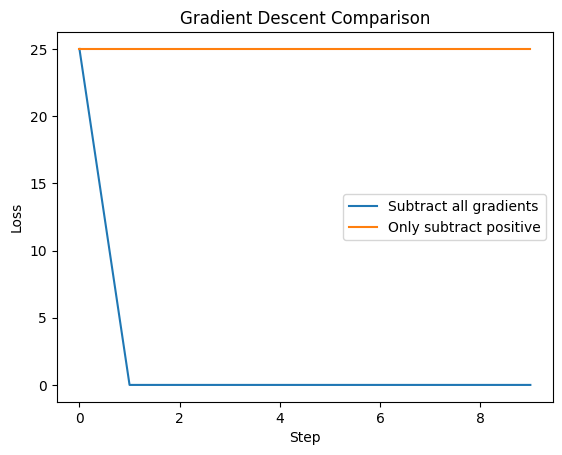

In [24]:
import torch
import matplotlib.pyplot as plt

target = 10.0
learning_rate = 0.5

# Method 1: Subtract ALL gradients (correct)
x1 = torch.tensor([5.0], requires_grad=True)
losses1 = []

for step in range(10):
    loss = (x1 - target) ** 2
    losses1.append(loss.item())
    loss.backward()
    with torch.no_grad():
        x1 -= learning_rate * x1.grad
    x1.grad.zero_()

# Method 2: Only subtract POSITIVE gradients (your idea)
x2 = torch.tensor([5.0], requires_grad=True)
losses2 = []

for step in range(10):
    loss = (x2 - target) ** 2
    losses2.append(loss.item())
    loss.backward()
    
    if x2.grad.item() > 0:  # Only if positive
        with torch.no_grad():
            x2 -= learning_rate * x2.grad
    
    x2.grad.zero_()

print(f"Method 1 (subtract all): x={x1.item():.2f}, final loss={losses1[-1]:.2f}")
print(f"Method 2 (only positive): x={x2.item():.2f}, final loss={losses2[-1]:.2f}")

# Plot
plt.plot(losses1, label='Subtract all gradients')
plt.plot(losses2, label='Only subtract positive')
plt.xlabel('Step')
plt.ylabel('Loss')
plt.legend()
plt.title('Gradient Descent Comparison')
plt.show()

In [15]:
import matplotlib.pyplot as plt

# True function we're trying to learn: y = 3x + 7
true_weight = 3.0
true_bias = 7.0

# Generate some training data
x_data = torch.randn(5)
y_data = true_weight * x_data + true_bias  # [10, 13, 16, 19, 22]

In [16]:
# Guesses (start wrong!)
weight = torch.tensor([0.0], requires_grad=True)
bias = torch.tensor([0.0], requires_grad=True)

learning_rate = 0.06
losses = []  # Track loss over time

for step in range(100):
    # 1. Make predictions using current weight and bias
    predictions = x_data * weight + bias
    
    # 2. Calculate loss (mean squared error)
    loss = (predictions - y_data) ** 2
    loss = loss.mean()
    
    # 3. Backward pass
    loss.backward()
    
    # 4. Update BOTH weight and bias
    with torch.no_grad():
        weight -= learning_rate * weight.grad
        bias -= learning_rate * bias.grad
    
    # 5. Zero gradients
    weight.grad.zero_()
    bias.grad.zero_()

    # Track progress
    losses.append(loss.item())
    
    if step % 10 == 0:
        print(f"Step {step}: Loss={loss.item():.4f}, Weight={weight.item():.4f}, Bias={bias.item():.4f}")

print(f"\n✅ Final learned parameters:")
print(f"Weight: {weight.item():.4f} (true: {true_weight})")
print(f"Bias: {bias.item():.4f} (true: {true_bias})")

Step 0: Loss=48.8649, Weight=0.0770, Bias=0.8047
Step 10: Loss=5.6328, Weight=0.9687, Bias=5.1023
Step 20: Loss=1.1215, Weight=1.7161, Bias=6.3584
Step 30: Loss=0.3295, Weight=2.2182, Bias=6.7514
Step 40: Loss=0.1106, Weight=2.5314, Bias=6.8886
Step 50: Loss=0.0384, Weight=2.7212, Bias=6.9438
Step 60: Loss=0.0134, Weight=2.8346, Bias=6.9694
Step 70: Loss=0.0047, Weight=2.9020, Bias=6.9826
Step 80: Loss=0.0016, Weight=2.9420, Bias=6.9899
Step 90: Loss=0.0006, Weight=2.9657, Bias=6.9941

✅ Final learned parameters:
Weight: 2.9786 (true: 3.0)
Bias: 6.9963 (true: 7.0)
